# Jaccpot GPU Runtime Benchmark (Radix Tree)

This notebook benchmarks Jaccpot runtime on GPU using yggdrax radix-tree settings tuned for throughput.

Included plots:
- `Runtime scaling with particle count (full vs prepared split)`
- `prepare_state component breakdown`

In [1]:
import os

# --- Option A: automatic GPU selection with autocvd ---
USE_AUTOCVD = False
AUTOCVD_NUM_GPUS = 1
AUTOCVD_LEAST_USED = True
AUTOCVD_EXCLUDE = []

# --- Option B: manual selection (set to string like '0' or '0,1') ---
MANUAL_CUDA_VISIBLE_DEVICES = "0"  # None #"1,2,3,4,5,6,7,8,9"#None

if MANUAL_CUDA_VISIBLE_DEVICES is not None:
    os.environ["CUDA_VISIBLE_DEVICES"] = MANUAL_CUDA_VISIBLE_DEVICES
    print("Set CUDA_VISIBLE_DEVICES =", os.environ["CUDA_VISIBLE_DEVICES"])
elif USE_AUTOCVD:
    try:
        from autocvd import autocvd

        autocvd(
            num_gpus=AUTOCVD_NUM_GPUS,
            least_used=AUTOCVD_LEAST_USED,
            exclude=AUTOCVD_EXCLUDE,
        )
        print(
            "autocvd selected CUDA_VISIBLE_DEVICES =",
            os.environ.get("CUDA_VISIBLE_DEVICES"),
        )
    except ImportError:
        print(
            "autocvd is not installed. Install it or set MANUAL_CUDA_VISIBLE_DEVICES."
        )
else:
    print(
        "Using existing CUDA visibility:",
        os.environ.get("CUDA_VISIBLE_DEVICES", "<all visible>"),
    )

# Index precision switch (must be set before importing JAX/jaccpot/yggdrax).
INDEX_PRECISION = "int32"  # choose from: "int32", "int64"
os.environ.setdefault("JACCPOT_INDEX_PRECISION", INDEX_PRECISION)
os.environ.setdefault("YGGDRAX_INDEX_PRECISION", INDEX_PRECISION)
print("Index precision:", os.environ.get("JACCPOT_INDEX_PRECISION"))

# GPU memory-fragmentation / graph-memory safeguards.
os.environ.setdefault("TF_GPU_ALLOCATOR", "cuda_malloc_async")
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
if "--xla_gpu_enable_command_buffer=" not in os.environ.get("XLA_FLAGS", ""):
    existing_xla_flags = os.environ.get("XLA_FLAGS", "").strip()
    command_buffer_off = "--xla_gpu_enable_command_buffer="
    os.environ["XLA_FLAGS"] = (
        f"{existing_xla_flags} {command_buffer_off}".strip()
        if existing_xla_flags
        else command_buffer_off
    )

Set CUDA_VISIBLE_DEVICES = 0
Index precision: int32


In [2]:
import json
from dataclasses import replace
import pathlib
import subprocess
import sys
import inspect
import time

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

REPO_ROOT = pathlib.Path.cwd().resolve()
if not (REPO_ROOT / "jaccpot").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

from jaccpot import (
    FMMAdvancedConfig,
    FMMPreset,
    FarFieldConfig,
    FastMultipoleMethod,
    NearFieldConfig,
    RuntimePolicyConfig,
    TreeConfig,
)
from yggdrax import Tree, compute_tree_geometry
from yggdrax.interactions import DualTreeTraversalConfig, build_interactions_and_neighbors

from examples import benchmark_utils as bench_utils

In [3]:
# GPU sanity check
all_devices = jax.devices()
gpu_devices = [d for d in all_devices if d.platform == "gpu"]
print("JAX backend:", jax.default_backend())
print("Visible devices:", all_devices)
if not gpu_devices:
    raise RuntimeError(
        "No GPU device visible to JAX. Ensure CUDA/ROCm is configured before running this notebook."
    )
print("Using GPU:", gpu_devices[0])

JAX backend: gpu
Visible devices: [CudaDevice(id=0)]
Using GPU: cuda:0


## Benchmark Configuration

In [4]:
# Particle-count sweep for scaling plots (includes your target N=131072)
runtime_particle_counts = [8192, 16384, 32768, 65536, 131072, 262144, 524288, 1048576, 2097152, 4194304, 8388608, 16777216]
runtime_leaf_size = 64
runtime_max_order = 4
runtime_runs = 3
runtime_warmup = 1
runtime_isolate_process_per_n = True
runtime_autotune_cache_path = REPO_ROOT / "benchmarks" / "m2l_autotune_cache.json"
runtime_traversal_autotune_cache_path = REPO_ROOT / "benchmarks" / "traversal_autotune_cache.json"
runtime_enable_traversal_autotune = True
runtime_traversal_autotune_probe_n = 131072
runtime_traversal_candidates = [
    dict(max_pair_queue=131072, process_block=128, max_interactions_per_node=1024, max_neighbors_per_leaf=256),
    dict(max_pair_queue=131072, process_block=256, max_interactions_per_node=2048, max_neighbors_per_leaf=512),
    dict(max_pair_queue=262144, process_block=256, max_interactions_per_node=4096, max_neighbors_per_leaf=1024),
    dict(max_pair_queue=524288, process_block=512, max_interactions_per_node=4096, max_neighbors_per_leaf=1024),
]


runtime_benchmark_scope = "steady_eval"
runtime_worker_autotune_traversal = True
runtime_worker_autotune_nearfield_chunk = True
runtime_nearfield_chunk_candidates = [64, 128, 256, 512]
runtime_runtime_autotune_cache_path = REPO_ROOT / "benchmarks" / "runtime_worker_autotune_cache.json"

# GPU-oriented precision for large-N profiling
runtime_precision = "fp32"
runtime_working_dtype = jnp.float32
runtime_adaptive_p_gears = (2, 3, 4)
runtime_adaptive_error_model = "dehnen_degree"
runtime_adaptive_eps = 5e-4
runtime_adaptive_mac_force_scale_mode = "prev"
autotune_warmup_counts = [65536, 131072]
apples_particle_counts = [65536, 131072, 262144, 524288]
apples_runs = 3
apples_warmup = 1
accuracy_particle_counts = [4096, 16384, 65536]
accuracy_direct_target_cap = 2048
accuracy_direct_target_chunk = 256
accuracy_direct_source_chunk = 4096
runtime_key = jax.random.PRNGKey(0)
softening = 1e-3

# Compare a fiducial large-N preset against adaptive-order + error-controlled MAC.
runtime_fmm_kwargs_fiducial = dict(
    preset=FMMPreset.LARGE_N_GPU,
    basis="solidfmm",
    precision=runtime_precision,
    theta=0.6,
    softening=softening,
    working_dtype=runtime_working_dtype,
    adaptive_order=False,
)
runtime_fmm_kwargs_adaptive = runtime_fmm_kwargs_fiducial.copy()
runtime_fmm_kwargs_adaptive.update(
    adaptive_order=True,
    p_gears=runtime_adaptive_p_gears,
    adaptive_error_model=runtime_adaptive_error_model,
    adaptive_eps=runtime_adaptive_eps,
    mac_force_scale_mode=runtime_adaptive_mac_force_scale_mode,
)
runtime_setups = {
    "fiducial": runtime_fmm_kwargs_fiducial,
    "adaptive_error_mac": runtime_fmm_kwargs_adaptive,
}

## Runtime Collection Helpers

In [5]:
def _evaluate_prepared_kwargs(fmm):
    params = inspect.signature(fmm.evaluate_prepared_state).parameters
    if "jit_traversal" in params:
        return {"jit_traversal": True}
    return {}


def _release_runtime_memory(fmm):
    clear_fn = getattr(fmm, "clear_runtime_caches", None)
    if callable(clear_fn):
        clear_fn(clear_jax_compilation=True)
        return
    if hasattr(fmm, "clear_prepared_state_cache"):
        fmm.clear_prepared_state_cache()
    jax.clear_caches()


def _serialize_fmm_kwargs_for_worker(fmm_kwargs):
    probe_fmm = FastMultipoleMethod(**fmm_kwargs)
    advanced = probe_fmm.advanced
    traversal_cfg = advanced.runtime.traversal_config
    traversal_payload = None
    if traversal_cfg is not None:
        traversal_payload = {
            "process_block": int(traversal_cfg.process_block),
            "max_neighbors_per_leaf": int(traversal_cfg.max_neighbors_per_leaf),
            "max_interactions_per_node": int(traversal_cfg.max_interactions_per_node),
            "max_pair_queue": int(traversal_cfg.max_pair_queue),
        }
    preset_value = fmm_kwargs.get("preset", "fast")
    if hasattr(preset_value, "value"):
        preset_value = preset_value.value
    payload = {
        "preset": str(preset_value),
        "basis": str(fmm_kwargs.get("basis", "solidfmm")),
        "theta": float(fmm_kwargs.get("theta", 0.6)),
        "softening": float(fmm_kwargs.get("softening", 1e-3)),
        "working_dtype": str(jnp.dtype(getattr(probe_fmm._impl, "working_dtype", jnp.float32))),
        "tree_type": str(advanced.tree.tree_type),
        "leaf_target": int(advanced.tree.leaf_target),
        "farfield_rotation": str(advanced.farfield.rotation),
        "farfield_mode": str(advanced.farfield.mode),
        "grouped_interactions": bool(advanced.farfield.grouped_interactions),
        "streamed_far_pairs": advanced.farfield.streamed_far_pairs,
        "mixed_order": bool(advanced.farfield.mixed_order),
        "mixed_order_min_order": advanced.farfield.mixed_order_min_order,
        "nearfield_mode": str(advanced.nearfield.mode),
        "nearfield_edge_chunk_size": int(advanced.nearfield.edge_chunk_size),
        "precompute_scatter_schedules": bool(advanced.nearfield.precompute_scatter_schedules),
        "pair_process_block": (
            None
            if advanced.runtime.pair_process_block is None
            else int(advanced.runtime.pair_process_block)
        ),
        "jit_traversal": bool(advanced.runtime.jit_traversal),
        "traversal_config": traversal_payload,
        "enable_interaction_cache": bool(advanced.runtime.enable_interaction_cache),
        "retain_traversal_result": bool(advanced.runtime.retain_traversal_result),
        "retain_interactions": bool(advanced.runtime.retain_interactions),
        "autotune_m2l_chunk": bool(advanced.runtime.autotune_m2l_chunk),
        "adaptive_order": bool(getattr(probe_fmm._impl, "adaptive_order", False)),
        "p_gears": [int(v) for v in getattr(probe_fmm._impl, "p_gears", tuple())],
        "adaptive_error_model": str(getattr(probe_fmm._impl, "adaptive_error_model", "tail_proxy")),
        "adaptive_eps": (
            None
            if getattr(probe_fmm._impl, "adaptive_eps", None) is None
            else float(getattr(probe_fmm._impl, "adaptive_eps"))
        ),
        "mac_force_scale_mode": str(getattr(probe_fmm._impl, "mac_force_scale_mode", "prev")),
        "mac_type": str(advanced.mac_type),
    }
    _release_runtime_memory(probe_fmm)
    return payload


def _run_worker_case(mode, *, num_particles, leaf_size, max_order, runs, warmup, dtype, fmm_kwargs):
    worker_script = REPO_ROOT / "examples" / "benchmark_gpu_radix_worker.py"
    payload = _serialize_fmm_kwargs_for_worker(fmm_kwargs)
    cmd = [
        sys.executable,
        str(worker_script),
        "--mode",
        str(mode),
        "--num-particles",
        str(int(num_particles)),
        "--leaf-size",
        str(int(leaf_size)),
        "--max-order",
        str(int(max_order)),
        "--runs",
        str(int(runs)),
        "--warmup",
        str(int(warmup)),
        "--dtype",
        str(jnp.dtype(dtype)),
        "--seed",
        "0",
        "--autotune-cache",
        str(runtime_autotune_cache_path),
        "--config-json",
        json.dumps(payload),
    ]
    result = subprocess.run(cmd, check=False, capture_output=True, text=True)
    if result.returncode != 0:
        details = (result.stderr or result.stdout or "").strip()
        raise RuntimeError(f"worker failed (exit={result.returncode}): {details}")
    lines = [line.strip() for line in result.stdout.splitlines() if line.strip()]
    if not lines:
        raise RuntimeError("worker produced no output")
    return json.loads(lines[-1])


def _load_json_cache(path):
    if not path.exists():
        return {}
    try:
        return json.loads(path.read_text())
    except Exception:
        return {}


def _save_json_cache(path, payload):
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(payload, indent=2, sort_keys=True))


def _apply_traversal_config(fmm_kwargs, traversal_cfg_dict):
    traversal_cfg = DualTreeTraversalConfig(
        max_pair_queue=int(traversal_cfg_dict["max_pair_queue"]),
        process_block=int(traversal_cfg_dict["process_block"]),
        max_interactions_per_node=int(traversal_cfg_dict["max_interactions_per_node"]),
        max_neighbors_per_leaf=int(traversal_cfg_dict["max_neighbors_per_leaf"]),
    )
    probe = FastMultipoleMethod(**fmm_kwargs)
    advanced = probe.advanced
    tuned_advanced = replace(
        advanced,
        runtime=replace(advanced.runtime, traversal_config=traversal_cfg),
    )
    _release_runtime_memory(probe)
    out = dict(fmm_kwargs)
    out["advanced"] = tuned_advanced
    return out


def _resolve_traversal_autotuned_kwargs(setup_name, fmm_kwargs):
    if not bool(runtime_enable_traversal_autotune):
        return fmm_kwargs, None

    cache = _load_json_cache(runtime_traversal_autotune_cache_path)
    entries = cache.get("entries", {}) if isinstance(cache, dict) else {}
    key = "|".join(
        [
            f"setup={setup_name}",
            f"leaf={int(runtime_leaf_size)}",
            f"order={int(runtime_max_order)}",
            f"dtype={str(jnp.dtype(runtime_working_dtype))}",
            f"theta={float(fmm_kwargs.get('theta', 0.6)):.4f}",
            f"idx={os.environ.get('JACCPOT_INDEX_PRECISION', 'int64')}",
        ]
    )
    cached = entries.get(key)
    if isinstance(cached, dict) and isinstance(cached.get("traversal_config"), dict):
        cfg = cached["traversal_config"]
        return _apply_traversal_config(fmm_kwargs, cfg), cfg

    probe_n = int(max(runtime_traversal_autotune_probe_n, max(autotune_warmup_counts)))
    selected_cfg = None
    for candidate in runtime_traversal_candidates:
        trial_kwargs = _apply_traversal_config(fmm_kwargs, candidate)
        try:
            row = _run_worker_case(
                "prepare",
                num_particles=probe_n,
                leaf_size=runtime_leaf_size,
                max_order=runtime_max_order,
                runs=1,
                warmup=0,
                dtype=runtime_working_dtype,
                fmm_kwargs=trial_kwargs,
            )
            prep_t = float(row.get("prepare_component_sum_seconds", float("nan")))
            if np.isfinite(prep_t):
                selected_cfg = {k: int(v) for k, v in candidate.items()}
                print(f"[traversal_autotune] setup={setup_name} accepted {selected_cfg} at N={probe_n}")
                break
        except Exception as exc:
            print(
                f"[traversal_autotune] setup={setup_name} candidate={candidate} failed: {type(exc).__name__}: {exc}"
            )

    if selected_cfg is None:
        print(
            f"[traversal_autotune] setup={setup_name} found no stable candidate; keeping preset traversal config"
        )
        return fmm_kwargs, None

    if not isinstance(cache, dict):
        cache = {}
    entries = cache.setdefault("entries", {})
    entries[key] = {
        "traversal_config": selected_cfg,
        "probe_n": int(probe_n),
    }
    _save_json_cache(runtime_traversal_autotune_cache_path, cache)
    return _apply_traversal_config(fmm_kwargs, selected_cfg), selected_cfg


def sweep_runtimes(
    particle_counts,
    *,
    leaf_size,
    max_order,
    runs,
    warmup,
    dtype,
    key,
    fmm_kwargs,
    strict=False,
):
    records = []
    use_subprocess = bool(globals().get("runtime_isolate_process_per_n", False))
    fmm = None if use_subprocess else FastMultipoleMethod(**fmm_kwargs)
    current_key = key

    for num_particles in particle_counts:
        try:
            if use_subprocess:
                records.append(
                    _run_worker_case(
                        "sweep",
                        num_particles=num_particles,
                        leaf_size=leaf_size,
                        max_order=max_order,
                        runs=runs,
                        warmup=warmup,
                        dtype=dtype,
                        fmm_kwargs=fmm_kwargs,
                    )
                )
                continue

            positions, masses, current_key = bench_utils.generate_random_distribution(
                num_particles,
                key=current_key,
                dtype=dtype,
            )

            benchmark_scope = str(globals().get("runtime_benchmark_scope", "steady_eval")).strip().lower()
            if benchmark_scope not in ("full", "steady_eval"):
                benchmark_scope = "steady_eval"

            prepare_once_timing = bench_utils.time_callable(
                fmm.prepare_state,
                positions,
                masses,
                leaf_size=leaf_size,
                max_order=max_order,
                warmup=warmup,
                runs=runs,
            )
            prepared_state = prepare_once_timing.result

            eval_kwargs = _evaluate_prepared_kwargs(fmm)
            eval_timing = bench_utils.time_callable(
                fmm.evaluate_prepared_state,
                prepared_state,
                warmup=warmup,
                runs=runs,
                **eval_kwargs,
            )

            if benchmark_scope == "full":
                full_timing = bench_utils.time_callable(
                    fmm.compute_accelerations,
                    positions,
                    masses,
                    leaf_size=leaf_size,
                    max_order=max_order,
                    reuse_prepared_state=False,
                    warmup=warmup,
                    runs=runs,
                )
                full_mean = full_timing.mean
                full_std = full_timing.std
            else:
                full_mean = eval_timing.mean
                full_std = eval_timing.std

            records.append(
                {
                    "num_particles": num_particles,
                    "mean_seconds": full_mean,
                    "std_seconds": full_std,
                    "prepare_mean_seconds": prepare_once_timing.mean,
                    "prepare_std_seconds": prepare_once_timing.std,
                    "evaluate_mean_seconds": eval_timing.mean,
                    "evaluate_std_seconds": eval_timing.std,
                    "benchmark_scope": benchmark_scope,
                    "error": "",
                }
            )
        except Exception as exc:
            msg = f"{type(exc).__name__}: {exc}"
            print(f"[sweep_runtimes] N={num_particles} failed: {msg}")
            records.append(
                {
                    "num_particles": num_particles,
                    "mean_seconds": float("nan"),
                    "std_seconds": float("nan"),
                    "prepare_mean_seconds": float("nan"),
                    "prepare_std_seconds": float("nan"),
                    "evaluate_mean_seconds": float("nan"),
                    "evaluate_std_seconds": float("nan"),
                    "error": msg,
                }
            )
            if strict:
                raise
        finally:
            if fmm is not None:
                _release_runtime_memory(fmm)

    return pd.DataFrame(records)


def profile_prepare_components(
    particle_counts,
    *,
    leaf_size,
    max_order,
    dtype,
    key,
    fmm_kwargs,
    runs,
    warmup,
    strict=False,
):
    records = []
    use_subprocess = bool(globals().get("runtime_isolate_process_per_n", False))
    fmm = None if use_subprocess else FastMultipoleMethod(**fmm_kwargs)
    current_key = key

    if not use_subprocess:
        tree_type = str(getattr(fmm._impl, "tree_type", "radix"))
        tree_mode = str(getattr(fmm._impl, "tree_build_mode", "lbvh"))
        ygg_build_mode = "fixed_depth" if tree_mode == "fixed_depth" else "adaptive"
        theta_val = float(getattr(fmm._impl, "theta", fmm_kwargs.get("theta", 0.6)))
        traversal_cfg = fmm.advanced.runtime.traversal_config
        mac_type = str(getattr(fmm, "mac_type", "dehnen"))
        dehnen_radius_scale = float(getattr(fmm._impl, "dehnen_radius_scale", 1.0))

    for num_particles in particle_counts:
        try:
            if use_subprocess:
                records.append(
                    _run_worker_case(
                        "prepare",
                        num_particles=num_particles,
                        leaf_size=leaf_size,
                        max_order=max_order,
                        runs=runs,
                        warmup=warmup,
                        dtype=dtype,
                        fmm_kwargs=fmm_kwargs,
                    )
                )
                continue

            positions, masses, current_key = bench_utils.generate_random_distribution(
                num_particles,
                key=current_key,
                dtype=dtype,
            )

            tree_timing = bench_utils.time_callable(
                Tree.from_particles,
                positions,
                masses,
                tree_type=tree_type,
                build_mode=ygg_build_mode,
                return_reordered=True,
                leaf_size=int(leaf_size),
                warmup=warmup,
                runs=runs,
            )

            tree = Tree.from_particles(
                positions,
                masses,
                tree_type=tree_type,
                build_mode=ygg_build_mode,
                return_reordered=True,
                leaf_size=int(leaf_size),
            )
            geometry = compute_tree_geometry(tree, tree.positions_sorted)

            interactions_timing = bench_utils.time_callable(
                build_interactions_and_neighbors,
                tree,
                geometry,
                theta=theta_val,
                traversal_config=traversal_cfg,
                mac_type=mac_type,
                dehnen_radius_scale=dehnen_radius_scale,
                warmup=warmup,
                runs=runs,
            )

            prepare_timing = bench_utils.time_callable(
                fmm.prepare_state,
                positions,
                masses,
                leaf_size=int(leaf_size),
                max_order=max_order,
                warmup=warmup,
                runs=runs,
            )

            residual = max(
                float(prepare_timing.mean)
                - float(tree_timing.mean)
                - float(interactions_timing.mean),
                0.0,
            )
            records.append(
                {
                    "num_particles": num_particles,
                    "tree_build_mean_seconds": float(tree_timing.mean),
                    "interactions_mean_seconds": float(interactions_timing.mean),
                    "upward_mean_seconds": residual,
                    "downward_mean_seconds": 0.0,
                    "prepare_component_sum_seconds": float(prepare_timing.mean),
                    "error": "",
                }
            )
        except Exception as exc:
            msg = f"{type(exc).__name__}: {exc}"
            print(f"[profile_prepare_components] N={num_particles} failed: {msg}")
            records.append(
                {
                    "num_particles": num_particles,
                    "tree_build_mean_seconds": float("nan"),
                    "upward_mean_seconds": float("nan"),
                    "interactions_mean_seconds": float("nan"),
                    "downward_mean_seconds": float("nan"),
                    "prepare_component_sum_seconds": float("nan"),
                    "error": msg,
                }
            )
            if strict:
                raise
        finally:
            if fmm is not None:
                _release_runtime_memory(fmm)

    return pd.DataFrame(records)

## Runtime Scaling (Full vs Prepared Split)

In [6]:
# 1) Resolve/persist traversal-capacity autotune per setup.
runtime_setups_tuned = {}
runtime_traversal_choices = {}
for setup_name, fmm_kwargs in runtime_setups.items():
    tuned_kwargs, chosen_cfg = _resolve_traversal_autotuned_kwargs(setup_name, fmm_kwargs)
    runtime_setups_tuned[setup_name] = tuned_kwargs
    runtime_traversal_choices[setup_name] = chosen_cfg
runtime_traversal_choices

# 2) Warm up M2L autotuning first so benchmark runs use persisted best chunk sizes.
for setup_name, fmm_kwargs in runtime_setups_tuned.items():
    for warm_n in autotune_warmup_counts:
        try:
            _ = _run_worker_case(
                "prepare",
                num_particles=warm_n,
                leaf_size=runtime_leaf_size,
                max_order=runtime_max_order,
                runs=1,
                warmup=0,
                dtype=runtime_working_dtype,
                fmm_kwargs=fmm_kwargs,
            )
        except Exception as exc:
            print(f"[autotune_warmup] setup={setup_name} N={warm_n} failed: {type(exc).__name__}: {exc}")

# 3) Runtime sweep for both setups.
runtime_results = {}
for setup_name, fmm_kwargs in runtime_setups_tuned.items():
    setup_df = sweep_runtimes(
        runtime_particle_counts,
        leaf_size=runtime_leaf_size,
        max_order=runtime_max_order,
        runs=runtime_runs,
        warmup=runtime_warmup,
        dtype=runtime_working_dtype,
        key=runtime_key,
        fmm_kwargs=fmm_kwargs,
    )
    setup_df["setup"] = setup_name
    runtime_results[setup_name] = setup_df.sort_values("num_particles")

runtime_compare_df = pd.concat(runtime_results.values(), ignore_index=True)
runtime_compare_df

[traversal_autotune] setup=fiducial found no stable candidate; keeping preset traversal config
[traversal_autotune] setup=adaptive_error_mac found no stable candidate; keeping preset traversal config
[sweep_runtimes] N=16777216 failed: RuntimeError: worker failed (exit=-11): E0308 17:11:31.227200 2572438 gpu_hlo_schedule.cc:868] The byte size of input/output arguments (105553116266496) exceeds the base limit (33828215193). This indicates an error in the calculation!
E0308 17:11:31.227293 2572444 gpu_hlo_schedule.cc:868] The byte size of input/output arguments (105553116266496) exceeds the base limit (33828215193). This indicates an error in the calculation!
E0308 17:11:31.228227 2572405 gpu_hlo_schedule.cc:868] The byte size of input/output arguments (57200374448144) exceeds the base limit (33828215193). This indicates an error in the calculation!
W0308 17:11:31.309560 2572412 bfc_allocator.cc:311] Allocator (GPU_0_bfc) ran out of memory trying to allocate 12.02GiB with freed_by_count=

,num_particles,mean_seconds,std_seconds,prepare_mean_seconds,prepare_std_seconds,evaluate_mean_seconds,evaluate_std_seconds,error,benchmark_scope,worker_traversal_config,worker_nearfield_edge_chunk_size,setup
0,8192,NaN,NaN,NaN,NaN,NaN,NaN,AttributeError: type object 'int32' has no att...,NaN,NaN,NaN,fiducial
1,16384,5.196720,0.077846,3.879627,1.024456,0.054666,0.006126,,full,NaN,NaN,fiducial
2,32768,5.604920,0.175189,5.411382,0.289297,0.089259,0.000292,,full,NaN,NaN,fiducial
3,65536,6.657148,1.336708,5.186474,0.076418,0.192207,0.003036,,full,NaN,NaN,fiducial
4,131072,11.657235,0.420638,9.648388,0.675744,0.452814,0.006138,,full,NaN,NaN,fiducial
5,262144,20.545431,0.852589,18.444239,1.209541,1.005643,0.003474,,full,NaN,NaN,fiducial
6,524288,39.144652,0.465513,36.697432,0.774088,2.236835,0.023409,,full,NaN,NaN,fiducial
7,1048576,NaN,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: Out of me...,NaN,NaN,NaN,fiducial
8,2097152,NaN,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: Out of me...,NaN,NaN,NaN,fiducial
9,4194304,NaN,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: Out of me...,NaN,NaN,NaN,fiducial


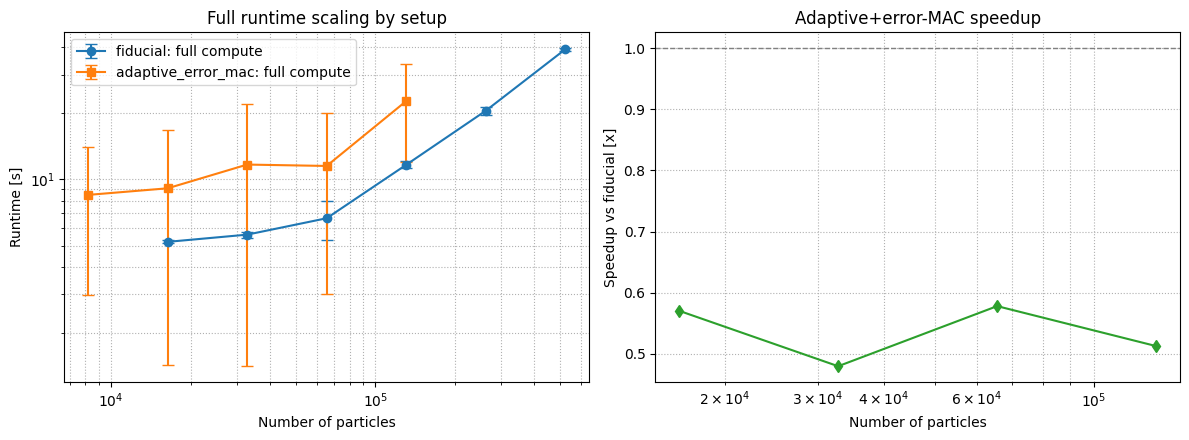

,num_particles,fiducial_s,adaptive_s,speedup_x
1,16384,5.196720,9.114439,0.570163
2,32768,5.604920,11.689938,0.479465
3,65536,6.657148,11.520808,0.577837
4,131072,11.657235,22.748781,0.512433


In [7]:
fig, (ax_rt, ax_sp) = plt.subplots(1, 2, figsize=(12, 4.5))

for setup_name, marker in [("fiducial", "o"), ("adaptive_error_mac", "s")]:
    df = runtime_results[setup_name]
    ax_rt.errorbar(
        df["num_particles"],
        df["mean_seconds"],
        yerr=df["std_seconds"],
        fmt=f"{marker}-",
        capsize=4,
        label=f"{setup_name}: full compute",
    )

ax_rt.set_xscale("log")
ax_rt.set_yscale("log")
ax_rt.set_xlabel("Number of particles")
ax_rt.set_ylabel("Runtime [s]")
ax_rt.set_title("Full runtime scaling by setup")
ax_rt.grid(True, which="both", linestyle=":", linewidth=0.8)
ax_rt.legend()

fid = runtime_results["fiducial"][["num_particles", "mean_seconds"]].rename(columns={"mean_seconds": "fiducial_s"})
ada = runtime_results["adaptive_error_mac"][["num_particles", "mean_seconds"]].rename(columns={"mean_seconds": "adaptive_s"})
speed = fid.merge(ada, on="num_particles", how="inner")
speed = speed[(speed["fiducial_s"] > 0) & (speed["adaptive_s"] > 0)].copy()
speed["speedup_x"] = speed["fiducial_s"] / speed["adaptive_s"]

ax_sp.plot(speed["num_particles"], speed["speedup_x"], "d-", color="tab:green")
ax_sp.axhline(1.0, color="gray", linestyle="--", linewidth=1)
ax_sp.set_xscale("log")
ax_sp.set_xlabel("Number of particles")
ax_sp.set_ylabel("Speedup vs fiducial [x]")
ax_sp.set_title("Adaptive+error-MAC speedup")
ax_sp.grid(True, which="both", linestyle=":", linewidth=0.8)

plt.tight_layout()
plt.show()

speed

## Prepare-State Component Breakdown

In [8]:
runtime_component_results = {}
for setup_name, fmm_kwargs in runtime_setups.items():
    comp_df = profile_prepare_components(
        runtime_particle_counts,
        leaf_size=runtime_leaf_size,
        max_order=runtime_max_order,
        dtype=runtime_working_dtype,
        key=runtime_key,
        fmm_kwargs=fmm_kwargs,
        runs=max(1, runtime_runs),
        warmup=runtime_warmup,
    )
    comp_df["setup"] = setup_name
    runtime_component_results[setup_name] = comp_df.sort_values("num_particles")

runtime_component_compare_df = pd.concat(runtime_component_results.values(), ignore_index=True)
runtime_component_compare_df

[profile_prepare_components] N=16777216 failed: RuntimeError: worker failed (exit=-11): E0308 18:03:16.942893 2637297 gpu_hlo_schedule.cc:868] The byte size of input/output arguments (105553116266496) exceeds the base limit (33828215193). This indicates an error in the calculation!
E0308 18:03:16.942976 2637305 gpu_hlo_schedule.cc:868] The byte size of input/output arguments (105553116266496) exceeds the base limit (33828215193). This indicates an error in the calculation!
E0308 18:03:16.943866 2637337 gpu_hlo_schedule.cc:868] The byte size of input/output arguments (57200374448144) exceeds the base limit (33828215193). This indicates an error in the calculation!
W0308 18:03:17.018680 2637341 bfc_allocator.cc:311] Allocator (GPU_0_bfc) ran out of memory trying to allocate 12.02GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
W0308 18:03:17.028456 2637330 bfc_allocator.cc:31

,num_particles,tree_build_mean_seconds,interactions_mean_seconds,upward_mean_seconds,downward_mean_seconds,prepare_component_sum_seconds,error,worker_traversal_config,worker_nearfield_edge_chunk_size,setup
0,8192,1.758951,0.027296,1.079163,0.0,2.865410,,NaN,NaN,fiducial
1,16384,1.571786,0.041559,2.315486,0.0,3.928831,,NaN,NaN,fiducial
2,32768,1.433095,0.058161,2.711177,0.0,4.202433,,NaN,NaN,fiducial
3,65536,1.620393,0.086870,3.533253,0.0,5.240516,,NaN,NaN,fiducial
4,131072,1.278115,0.116132,8.377010,0.0,9.771258,,NaN,NaN,fiducial
5,262144,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: Out of me...,NaN,NaN,fiducial
6,524288,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: Out of me...,NaN,NaN,fiducial
7,1048576,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: Out of me...,NaN,NaN,fiducial
8,2097152,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: Out of me...,NaN,NaN,fiducial
9,4194304,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: Out of me...,NaN,NaN,fiducial


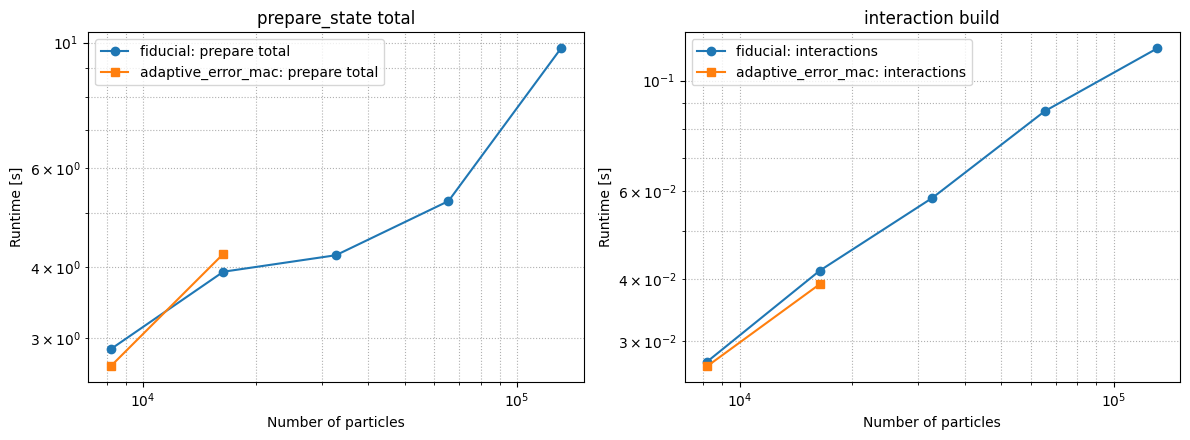

In [9]:
fig, (ax_sum, ax_int) = plt.subplots(1, 2, figsize=(12, 4.5))
for setup_name, marker in [("fiducial", "o"), ("adaptive_error_mac", "s")]:
    cdf = runtime_component_results[setup_name]
    ax_sum.plot(
        cdf["num_particles"],
        cdf["prepare_component_sum_seconds"],
        marker=marker,
        label=f"{setup_name}: prepare total",
    )
    ax_int.plot(
        cdf["num_particles"],
        cdf["interactions_mean_seconds"],
        marker=marker,
        label=f"{setup_name}: interactions",
    )

for ax, title, ylabel in [
    (ax_sum, "prepare_state total", "Runtime [s]"),
    (ax_int, "interaction build", "Runtime [s]"),
]:
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Number of particles")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, which="both", linestyle=":", linewidth=0.8)
    ax.legend()

plt.tight_layout()
plt.show()

In [10]:
runtime_index_precision = os.environ.get("JACCPOT_INDEX_PRECISION", "int64")

def _setup_traversal_cfg_value(setup_name, key):
    cfg = runtime_traversal_choices.get(str(setup_name)) if "runtime_traversal_choices" in globals() else None
    if not isinstance(cfg, dict):
        return np.nan
    val = cfg.get(str(key))
    return np.nan if val is None else int(val)

def _row_worker_traversal_cfg_value(worker_cfg, setup_name, key):
    if isinstance(worker_cfg, dict):
        val = worker_cfg.get(str(key))
        if val is not None:
            return int(val)
    return _setup_traversal_cfg_value(setup_name, key)

runtime_compare_df = runtime_compare_df.copy()
runtime_compare_df["index_precision"] = str(runtime_index_precision)
if "worker_traversal_config" not in runtime_compare_df.columns:
    runtime_compare_df["worker_traversal_config"] = None
if "worker_nearfield_edge_chunk_size" not in runtime_compare_df.columns:
    runtime_compare_df["worker_nearfield_edge_chunk_size"] = np.nan
if "benchmark_scope" not in runtime_compare_df.columns:
    runtime_compare_df["benchmark_scope"] = str(globals().get("runtime_benchmark_scope", "steady_eval"))

runtime_compare_df["traversal_tuned"] = runtime_compare_df.apply(
    lambda row: isinstance(row.get("worker_traversal_config"), dict)
    or isinstance((runtime_traversal_choices.get(str(row.get("setup"))) if "runtime_traversal_choices" in globals() else None), dict),
    axis=1,
)
for _key in [
    "max_pair_queue",
    "process_block",
    "max_interactions_per_node",
    "max_neighbors_per_leaf",
]:
    runtime_compare_df[f"traversal_{_key}"] = runtime_compare_df.apply(
        lambda row, k=_key: _row_worker_traversal_cfg_value(
            row.get("worker_traversal_config"),
            row.get("setup"),
            k,
        ),
        axis=1,
    )

runtime_compare_df["nearfield_edge_chunk_size"] = runtime_compare_df["worker_nearfield_edge_chunk_size"].map(
    lambda v: int(v) if pd.notna(v) else np.nan
)

runtime_config_summary_df = runtime_compare_df[
    [
        "setup",
        "num_particles",
        "index_precision",
        "traversal_tuned",
        "traversal_max_pair_queue",
        "traversal_process_block",
        "traversal_max_interactions_per_node",
        "traversal_max_neighbors_per_leaf",
        "nearfield_edge_chunk_size",
        "benchmark_scope",
        "worker_traversal_config",
        "worker_nearfield_edge_chunk_size",
        "mean_seconds",
        "prepare_mean_seconds",
        "evaluate_mean_seconds",
        "error",
    ]
].sort_values(["setup", "num_particles"])
runtime_config_summary_df

,setup,num_particles,index_precision,traversal_tuned,traversal_max_pair_queue,traversal_process_block,traversal_max_interactions_per_node,traversal_max_neighbors_per_leaf,nearfield_edge_chunk_size,benchmark_scope,worker_traversal_config,worker_nearfield_edge_chunk_size,mean_seconds,prepare_mean_seconds,evaluate_mean_seconds,error
12,adaptive_error_mac,8192,int32,False,NaN,NaN,NaN,NaN,NaN,full,NaN,NaN,8.505032,3.431044,0.017889,
13,adaptive_error_mac,16384,int32,False,NaN,NaN,NaN,NaN,NaN,full,NaN,NaN,9.114439,4.529635,0.038413,
14,adaptive_error_mac,32768,int32,False,NaN,NaN,NaN,NaN,NaN,full,NaN,NaN,11.689938,4.088474,0.077226,
15,adaptive_error_mac,65536,int32,False,NaN,NaN,NaN,NaN,NaN,full,NaN,NaN,11.520808,5.424794,0.142519,
16,adaptive_error_mac,131072,int32,False,NaN,NaN,NaN,NaN,NaN,full,NaN,NaN,22.748781,9.983939,0.243203,
17,adaptive_error_mac,262144,int32,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: Out of me...
18,adaptive_error_mac,524288,int32,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: Out of me...
19,adaptive_error_mac,1048576,int32,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: Out of me...
20,adaptive_error_mac,2097152,int32,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: Out of me...
21,adaptive_error_mac,4194304,int32,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: Out of me...


## Apples-To-Apples Timing Breakdown

This section separates cold prepare, hot prepare, hot evaluate, and full acceleration calls to compare end-to-end vs steady-state kernel throughput.

In [ ]:
def _block_ready(value):
    return jax.tree_util.tree_map(
        lambda x: x.block_until_ready() if hasattr(x, "block_until_ready") else x,
        value,
    )


apples_rows = []
apples_key = runtime_key
apples_setups = runtime_setups_tuned if "runtime_setups_tuned" in globals() else runtime_setups
for setup_name, fmm_kwargs in apples_setups.items():
    for n_particles in apples_particle_counts:
        positions, masses, apples_key = bench_utils.generate_random_distribution(
            int(n_particles),
            key=apples_key,
            dtype=runtime_working_dtype,
        )
        row = {
            "setup": setup_name,
            "num_particles": int(n_particles),
            "prepare_cold_seconds": np.nan,
            "prepare_hot_mean_seconds": np.nan,
            "evaluate_hot_mean_seconds": np.nan,
            "full_rebuild_mean_seconds": np.nan,
            "full_reuse_mean_seconds": np.nan,
            "eval_particles_per_sec": np.nan,
            "full_rebuild_particles_per_sec": np.nan,
            "error": "",
        }
        fmm = None
        try:
            fmm = FastMultipoleMethod(**fmm_kwargs)
            if runtime_autotune_cache_path.exists():
                fmm.load_m2l_autotune_cache(str(runtime_autotune_cache_path), merge=True)

            t0 = time.perf_counter()
            state_cold = fmm.prepare_state(
                positions,
                masses,
                leaf_size=runtime_leaf_size,
                max_order=runtime_max_order,
            )
            _ = _block_ready(state_cold)
            row["prepare_cold_seconds"] = float(time.perf_counter() - t0)

            prep_hot = bench_utils.time_callable(
                fmm.prepare_state,
                positions,
                masses,
                leaf_size=runtime_leaf_size,
                max_order=runtime_max_order,
                warmup=apples_warmup,
                runs=apples_runs,
            )
            row["prepare_hot_mean_seconds"] = float(prep_hot.mean)

            eval_hot = bench_utils.time_callable(
                fmm.evaluate_prepared_state,
                prep_hot.result,
                warmup=apples_warmup,
                runs=apples_runs,
                **_evaluate_prepared_kwargs(fmm),
            )
            row["evaluate_hot_mean_seconds"] = float(eval_hot.mean)

            full_rebuild = bench_utils.time_callable(
                fmm.compute_accelerations,
                positions,
                masses,
                leaf_size=runtime_leaf_size,
                max_order=runtime_max_order,
                reuse_prepared_state=False,
                warmup=apples_warmup,
                runs=apples_runs,
            )
            row["full_rebuild_mean_seconds"] = float(full_rebuild.mean)

            full_reuse = bench_utils.time_callable(
                fmm.compute_accelerations,
                positions,
                masses,
                leaf_size=runtime_leaf_size,
                max_order=runtime_max_order,
                reuse_prepared_state=True,
                warmup=apples_warmup,
                runs=apples_runs,
            )
            row["full_reuse_mean_seconds"] = float(full_reuse.mean)

            if np.isfinite(row["evaluate_hot_mean_seconds"]) and row["evaluate_hot_mean_seconds"] > 0:
                row["eval_particles_per_sec"] = float(
                    n_particles / row["evaluate_hot_mean_seconds"]
                )
            if np.isfinite(row["full_rebuild_mean_seconds"]) and row["full_rebuild_mean_seconds"] > 0:
                row["full_rebuild_particles_per_sec"] = float(
                    n_particles / row["full_rebuild_mean_seconds"]
                )
        except Exception as exc:
            row["error"] = f"{type(exc).__name__}: {exc}"
            print(f"[apples] setup={setup_name} N={n_particles} failed: {row['error']}")
        finally:
            if fmm is not None:
                _release_runtime_memory(fmm)
        apples_rows.append(row)

apples_df = pd.DataFrame(apples_rows).sort_values(["setup", "num_particles"])
apples_df

In [ ]:
apples_summary_df = apples_df[
    [
        "setup",
        "num_particles",
        "prepare_cold_seconds",
        "prepare_hot_mean_seconds",
        "evaluate_hot_mean_seconds",
        "full_rebuild_mean_seconds",
        "full_reuse_mean_seconds",
        "eval_particles_per_sec",
        "full_rebuild_particles_per_sec",
        "error",
    ]
]
apples_summary_df

,setup,num_particles,prepare_cold_seconds,prepare_hot_mean_seconds,evaluate_hot_mean_seconds,full_rebuild_mean_seconds,full_reuse_mean_seconds,eval_particles_per_sec,full_rebuild_particles_per_sec,error
4,adaptive_error_mac,65536,95.196847,5.634556,0.115623,17.967538,0.352852,566806.629671,3647.466795,
5,adaptive_error_mac,131072,99.104288,10.576746,0.241700,19.360232,1.017541,542292.393025,6770.166744,
6,adaptive_error_mac,262144,112.575752,19.336451,0.535221,38.027789,1.059520,489786.876056,6893.485185,
7,adaptive_error_mac,524288,132.322216,36.938371,1.113007,57.953674,2.418044,471055.254875,9046.674026,
0,fiducial,65536,84.885102,5.375349,0.193315,6.715606,0.452405,339011.522289,9758.761703,
1,fiducial,131072,99.121036,10.395806,0.450168,11.835302,1.174602,291162.195891,11074.664366,
2,fiducial,262144,104.017467,19.857861,1.014152,21.043686,1.533838,258485.867787,12457.133065,
3,fiducial,524288,125.497685,38.046313,2.243576,40.117476,3.222254,233684.041233,13068.818248,


## Accuracy Comparison (Vs Direct Sum)

Both setups are measured against a direct-sum reference. For large `N`, the reference is computed on a deterministic subset of targets to keep cost manageable.

In [ ]:
def _deterministic_sample_indices(n_items: int, cap: int | None) -> np.ndarray:
    if cap is None or cap <= 0 or n_items <= cap:
        return np.arange(n_items, dtype=np.int64)
    # Deterministic even-coverage sampling (no RNG variance in accuracy metrics).
    return np.linspace(0, n_items - 1, num=cap, dtype=np.int64)


def _direct_sum_accelerations_chunked(
    positions,
    masses,
    *,
    G: float,
    softening: float,
    target_indices,
    target_chunk: int,
    source_chunk: int,
):
    pos = np.asarray(positions)
    mass = np.asarray(masses)
    targets = np.asarray(target_indices, dtype=np.int64)
    out = np.zeros((targets.size, 3), dtype=pos.dtype)
    eps = np.finfo(pos.dtype).eps
    soft_sq = softening * softening

    for t0 in range(0, targets.size, target_chunk):
        t1 = min(t0 + target_chunk, targets.size)
        tidx = targets[t0:t1]
        p_t = pos[tidx]
        acc_t = np.zeros((tidx.size, 3), dtype=pos.dtype)

        for s0 in range(0, pos.shape[0], source_chunk):
            s1 = min(s0 + source_chunk, pos.shape[0])
            sidx = np.arange(s0, s1, dtype=np.int64)
            p_s = pos[s0:s1]
            m_s = mass[s0:s1]

            diff = p_t[:, None, :] - p_s[None, :, :]
            dist_sq = np.einsum("ijk,ijk->ij", diff, diff) + soft_sq
            dist = np.sqrt(dist_sq)
            inv_dist3 = 1.0 / (dist_sq * dist + eps)

            same = tidx[:, None] == sidx[None, :]
            inv_dist3[same] = 0.0

            weighted = m_s[None, :] * inv_dist3
            acc_t += -G * np.einsum("ij,ijk->ik", weighted, diff)

        out[t0:t1] = acc_t

    return out


accuracy_rows = []
acc_key = runtime_key
for n_particles in accuracy_particle_counts:
    positions, masses, acc_key = bench_utils.generate_random_distribution(
        int(n_particles),
        key=acc_key,
        dtype=runtime_working_dtype,
    )

    target_idx = _deterministic_sample_indices(int(n_particles), accuracy_direct_target_cap)
    acc_ref = _direct_sum_accelerations_chunked(
        positions,
        masses,
        G=1.0,
        softening=float(softening),
        target_indices=target_idx,
        target_chunk=int(accuracy_direct_target_chunk),
        source_chunk=int(accuracy_direct_source_chunk),
    )

    setup_fmms = {
        "fiducial": FastMultipoleMethod(**runtime_fmm_kwargs_fiducial),
        "adaptive_error_mac": FastMultipoleMethod(**runtime_fmm_kwargs_adaptive),
    }
    for setup_name, fmm in setup_fmms.items():
        if runtime_autotune_cache_path.exists():
            try:
                fmm.load_m2l_autotune_cache(str(runtime_autotune_cache_path), merge=True)
            except Exception as exc:
                print(f"[accuracy:{setup_name}] autotune cache load failed for N={n_particles}: {type(exc).__name__}: {exc}")

        acc_est = fmm.compute_accelerations(
            positions,
            masses,
            leaf_size=runtime_leaf_size,
            max_order=runtime_max_order,
            reuse_prepared_state=False,
        )
        acc_est_subset = np.asarray(acc_est)[target_idx]
        diff = acc_est_subset - acc_ref
        ref_norm = np.linalg.norm(acc_ref)
        rel_l2 = float(np.linalg.norm(diff) / max(ref_norm, 1e-12))
        denom = np.linalg.norm(acc_ref, axis=1)
        err = np.linalg.norm(diff, axis=1)
        rel_max = float(np.max(err / np.maximum(denom, 1e-12)))
        max_abs = float(np.max(np.abs(diff)))

        accuracy_rows.append(
            {
                "setup": setup_name,
                "num_particles": int(n_particles),
                "num_reference_targets": int(target_idx.size),
                "relative_l2": rel_l2,
                "relative_max": rel_max,
                "max_abs": max_abs,
            }
        )

        fmm.clear_runtime_caches(clear_jax_compilation=True)

accuracy_df = pd.DataFrame(accuracy_rows).sort_values(["setup", "num_particles"])
accuracy_df

,setup,num_particles,num_reference_targets,relative_l2,relative_max,max_abs
1,adaptive_error_mac,4096,2048,4.287768,26.897457,693753.000000
3,adaptive_error_mac,16384,2048,0.394029,4.724338,79202.367188
5,adaptive_error_mac,65536,2048,0.661095,3.406178,147982.781250
0,fiducial,4096,2048,4.288076,26.902653,693963.125000
2,fiducial,16384,2048,0.199068,4.141353,77997.421875
4,fiducial,65536,2048,0.414628,2.692477,137585.828125


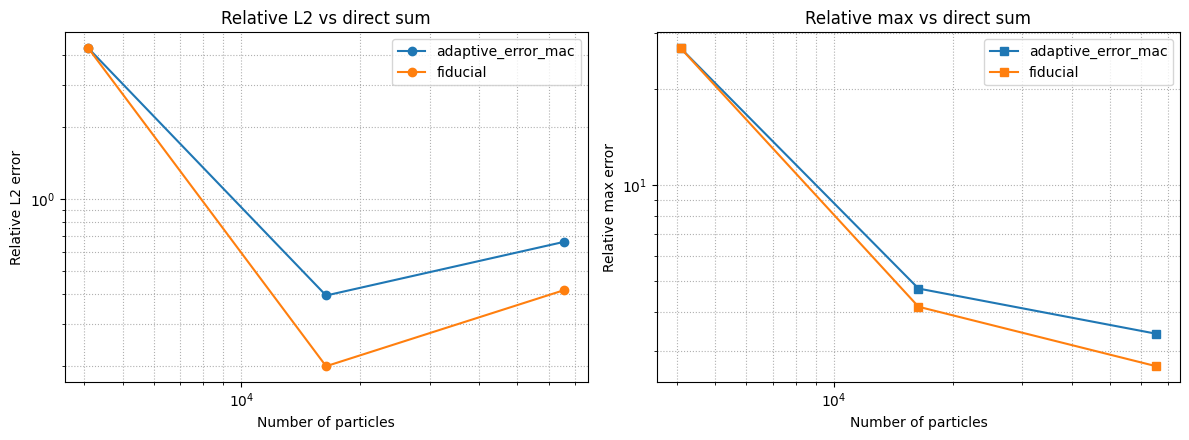

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)
for setup_name, sdf in accuracy_df.groupby("setup"):
    axes[0].plot(sdf["num_particles"], sdf["relative_l2"], "o-", label=setup_name)
    axes[1].plot(sdf["num_particles"], sdf["relative_max"], "s-", label=setup_name)

for ax, title, ylabel in [
    (axes[0], "Relative L2 vs direct sum", "Relative L2 error"),
    (axes[1], "Relative max vs direct sum", "Relative max error"),
]:
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Number of particles")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, which="both", linestyle=":", linewidth=0.8)
    ax.legend()

plt.tight_layout()
plt.show()

## Notes

- This notebook is GPU-focused and will fail early if no GPU is visible to JAX.
- `JACCPOT_INDEX_PRECISION` / `YGGDRAX_INDEX_PRECISION` is set at notebook start (`INDEX_PRECISION`) to switch index width (`int32`/`int64`). Restart kernel after changes.
- `runtime_autotune_cache_path` persists M2L chunk tuning across worker processes and future runs.
- `runtime_traversal_autotune_cache_path` persists traversal-capacity tuning (queue/block/neighbor/interaction caps) chosen from `runtime_traversal_candidates`.
- `runtime_runtime_autotune_cache_path` persists worker-selected runtime tuning (`worker_traversal_config`, `worker_nearfield_edge_chunk_size`) keyed by GPU/runtime signature.
- `runtime_benchmark_scope` defaults to `steady_eval` (hot prepared-state evaluation). Set to `full` for end-to-end rebuild timing.
- Runtime benchmarking compares two setups:
  - `fiducial` (`large_n_gpu` preset)
  - `adaptive_error_mac` (adaptive expansion order + error-controlled MAC)
- `runtime_worker_autotune_traversal` / `runtime_worker_autotune_nearfield_chunk` enable worker-side tuning (enabled by default in this notebook).
- Accuracy is measured against a chunked direct-sum reference. For large `N`, a deterministic target subset is used (`accuracy_direct_target_cap`).
- Run the notebook from the first cell so GPU/XLA environment flags are applied before JAX initializes.